## Business Problem:
-The E-commerce company is experiencing inconsistent revenue growth.
-The goal is to analyze sales data to identify key revenue drivers, customers purchasing behavior, and areas of improvement to increase overall sales


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.DataFrame({"sales":[100, 200,300
                            ]})

In [1]:
import pandas as pd 

orders = pd.read_csv("C:\orders.csv\olist_orders_dataset.csv")
order_items = pd.read_csv("C:\orders.csv\olist_order_items_dataset.csv")
products = pd.read_csv("C:\orders.csv\olist_products_dataset.csv")
customers = pd.read_csv("C:\orders.csv\olist_customers_dataset.csv")
payments = pd.read_csv("C:\orders.csv\olist_order_payments_dataset.csv")
location = pd.read_csv("C:\orders.csv\olist_geolocation_dataset.csv")
orders.head()
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [2]:
# step 1: orders + customers
df = pd.merge(orders, customers, on="customer_id", how="left")

# step 2: add order_items
df = pd.merge(df, order_items, on="order_id", how="left")

# step 3: add products
df = pd.merge(df, products, on="product_id", how="left")

#step 4: add payments
df = pd.merge(df, payments, on="order_id", how="left")

In [3]:
df.head()
df.shape

(118434, 30)

In [4]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

In [5]:
df.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    3397
product_photos_qty               2528
product_category_name            2528
product_name_lenght              2528
product_description_lenght       2528
order_delivered_carrier_date     2074
product_weight_g                  850
product_length_cm                 850
product_height_cm                 850
product_width_cm                  850
product_id                        830
order_item_id                     830
shipping_limit_date               830
seller_id                         830
price                             830
freight_value                     830
order_approved_at                 176
payment_sequential                  3
payment_installments                3
payment_type                        3
payment_value                       3
customer_city                       0
customer_id                         0
customer_state                      0
customer_unique_id                  0
customer_zip_code_prefix            0
order_estima

In [6]:
df['payment_value'].fillna(0,inplace=True)


C:\Users\rahul\AppData\Local\Temp\ipykernel_18348\487304216.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['payment_value'].fillna(0,inplace=True)


In [7]:
df['product_category_name'].fillna("Unknown", inplace=True)

C:\Users\rahul\AppData\Local\Temp\ipykernel_18348\2521166583.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_category_name'].fillna("Unknown", inplace=True)


In [8]:
df['order_purchase_timestamp']= pd.to_datetime(df['order_purchase_timestamp'])

In [9]:
# month
df['month'] = df['order_purchase_timestamp'].dt.month

In [10]:
#year
df['year'] = df['order_purchase_timestamp'].dt.year

In [11]:
# day of week
df['day'] = df['order_purchase_timestamp'].dt.day_name()

In [12]:
# negative value
df[df['payment_value']<0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,month,year,day


In [13]:
# column names clean
df.columns = df.columns.str.lower().str.strip()

In [14]:
# clean data save 
df.to_csv("C:\orders.csv\cleaned_data.csv",index=False)

In [15]:
df.shape
df.head()
df.describe()

,order_purchase_timestamp,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,month,year
count,118434,118434.000000,117604.000000,117604.000000,117604.000000,115906.000000,115906.000000,115906.000000,117584.000000,117584.000000,117584.00000,117584.000000,118431.000000,118431.000000,118434.000000,118434.000000,118434.000000
mean,2017-12-30 04:00:24.559636480,35034.264392,1.195920,120.822849,20.045551,48.767208,786.957302,2.207849,2114.281067,30.256872,16.63029,23.068394,1.094207,2.937398,172.845016,6.033723,2017.536324
min,2016-09-04 21:15:19,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.00000,6.000000,1.000000,0.000000,0.000000,1.000000,2016.000000
25%,2017-09-11 12:53:55.249999872,11310.000000,1.000000,39.900000,13.080000,42.000000,347.000000,1.000000,300.000000,18.000000,8.00000,15.000000,1.000000,1.000000,60.860000,3.000000,2017.000000
50%,2018-01-17 17:57:56.500000,24240.000000,1.000000,74.900000,16.290000,52.000000,601.000000,1.000000,700.000000,25.000000,13.00000,20.000000,1.000000,2.000000,108.200000,6.000000,2018.000000
75%,2018-05-03 19:05:01,58464.500000,1.000000,134.900000,21.190000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.00000,30.000000,1.000000,4.000000,189.240000,8.000000,2018.000000
max,2018-10-17 17:30:18,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.00000,118.000000,29.000000,24.000000,13664.080000,12.000000,2018.000000
std,NaN,29819.290218,0.697721,184.477367,15.861351,10.035162,653.029009,1.719519,3788.754048,16.190874,13.45878,11.748372,0.728290,2.774164,268.257844,3.231805,0.505492


<Axes: xlabel='year,month'>

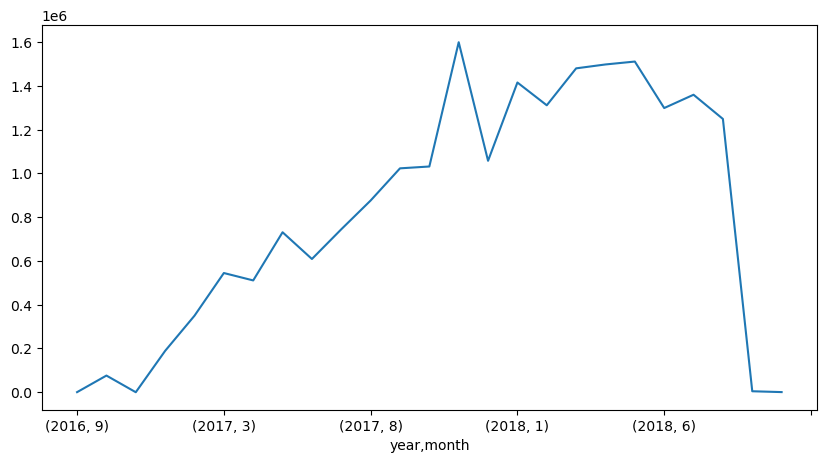

In [16]:
#sales trend analysis 
#month
monthly_sales = df.groupby(['year','month'])['payment_value'].sum()
monthly_sales.plot(figsize=(10,5))

<Axes: xlabel='product_id'>

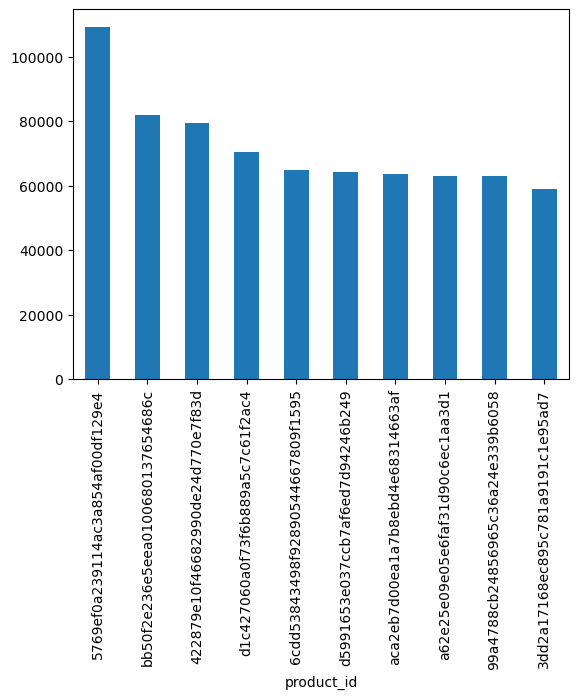

In [17]:
#top product 
top_products = df.groupby('product_id')['payment_value'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')

In [18]:
#category analysis
df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10)

product_category_name
cama_mesa_banho           1712553.67
beleza_saude              1657373.12
informatica_acessorios    1585330.45
moveis_decoracao          1430176.39
relogios_presentes        1429216.68
esporte_lazer             1392127.56
utilidades_domesticas     1094758.13
automotivo                 852294.33
ferramentas_jardim         838280.75
cool_stuff                 779698.00
Name: payment_value, dtype: float64

In [19]:
#customer analysis 
df['customer_unique_id'].nunique()

96096

In [20]:
#repeat vs new customer
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()
repeat = (customer_orders > 1).sum()
new = (customer_orders == 1).sum()

In [21]:
#location analysis
df['customer_city'].value_counts().head(10)

customer_city
sao paulo                18738
rio de janeiro            8252
belo horizonte            3272
brasilia                  2473
curitiba                  1820
campinas                  1750
porto alegre              1662
salvador                  1534
guarulhos                 1412
sao bernardo do campo     1122
Name: count, dtype: int64

<Axes: xlabel='payment_type'>

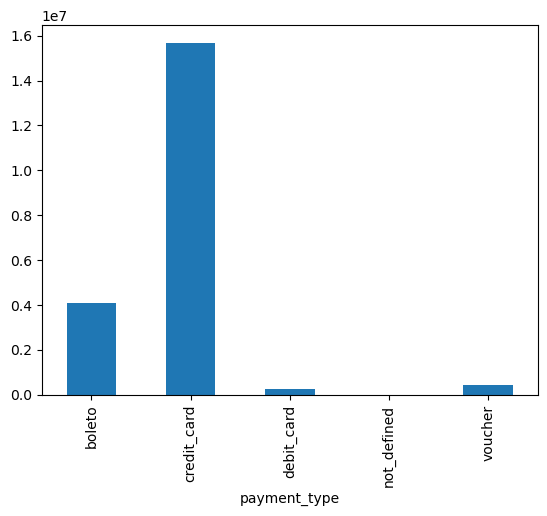

In [22]:
#payment analysis
df.groupby('payment_type')['payment_value'].sum().plot(kind='bar')